In [13]:
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [20]:
classification_results = pd.read_csv("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/src/stages/pattern_classification/models/metrics/1768798444.9018228/ensemble_classification_predictions.csv")

In [ ]:
y_true = classification_results['verified_pattern']
y_pred = classification_results['second_level_model_class_rr']
class_labels = np.unique(np.concatenate([y_true, y_pred]))


cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\n\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

print(f"With thresholding applied [precision]: {classification_report(y_true, classification_results['threshold_class'], target_names=class_labels, output_dict=True, zero_division=0)['weighted avg']['precision']:.4f}")
print(f"Without thresholding [precision]: {classification_report(y_true, classification_results['without_threshold_class'], target_names=class_labels, output_dict=True, zero_division=0)['weighted avg']['precision']:.4f}")
print(f"Second Level Model LR [precision]: {classification_report(y_true, classification_results['second_level_model_class_lr'], target_names=class_labels, output_dict=True, zero_division=0)['weighted avg']['precision']:.4f}")
print(f"Second Level Model RR [precision]: {classification_report(y_true, classification_results['second_level_model_class_rr'], target_names=class_labels, output_dict=True, zero_division=0)['weighted avg']['precision']:.4f}")


Confusion Matrix:
 [[31  0  3  0  0  5  2  1  5]
 [ 1  4  1  0  2  1  0  1  3]
 [ 4  0 14  0  0  2  0  0  6]
 [ 1  0  0  7  2  1  1  1  3]
 [ 0  2  0  0 10  0  0  4  4]
 [ 4  0  6  1  0 14  1  1  7]
 [ 0  0  0  3  1  3 10  0  3]
 [ 0  0  1  2  4  1  0  9 10]
 [11  0  5  2  2  7  5  3 29]]


Classification Report:
                                                            precision    recall  f1-score   support

                                         Classical Models       0.60      0.66      0.63        47
                                   LLM Results Evaluation       0.67      0.31      0.42        13
                LLM based Multimodal Generative Prompting       0.47      0.54      0.50        26
                                Model Abstraction Pattern       0.47      0.44      0.45        16
                          Modular LLM Agent Architectures       0.48      0.50      0.49        20
                    Preprocessing Text and Numerical Data       0.41      0.41      0.41 

ValueError: Number of classes, 10, does not match size of target_names, 9. Try specifying the labels parameter

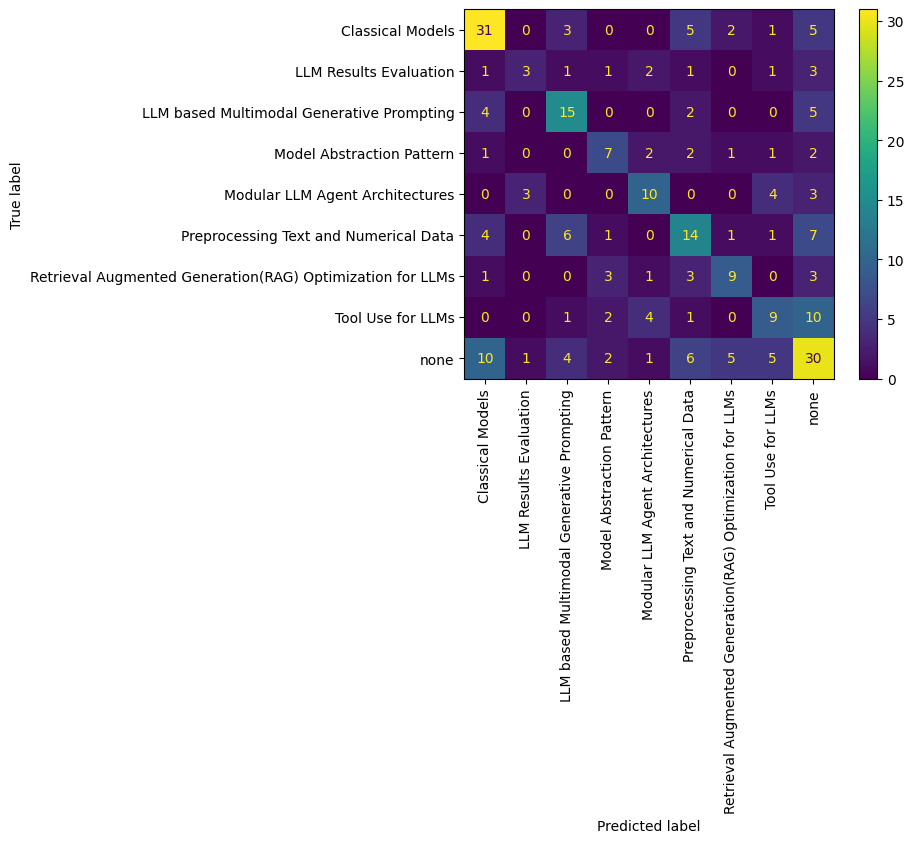

In [11]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

disp.plot()
plt.xticks(rotation=90)
plt.show()